In [6]:
# -*- coding: utf-8 -*-

# Proyecto: Mining Supply Chain Decision Intelligence

# Notebook 02 - EDA + Feature Engineering

### Objetivo
--------
Explorar el dataset sintético generado en el Notebook 01 y construir variables
útiles para modelado supervisado y para el futuro entorno de aprendizaje por refuerzo.

Este notebook cumple 3 funciones clave:
1) Entender el comportamiento del negocio mediante análisis exploratorio.
2) Construir features robustas y reproducibles.
3) Exportar datasets listos para modelado y dashboard.

### Diseño del notebook
-------------------
- Carga de datos desde /content/project_data
- Validaciones básicas de calidad
- EDA orientado a negocio
- Ingeniería de variables temporales, agregadas y de riesgo
- Preparación de dataset final para modelos posteriores
- Exportación a CSV

### Buenas prácticas aplicadas
--------------------------
- Código modular con funciones pequeñas.
- Parámetros centralizados.
- Comentarios claros y orientados a negocio.
- Separación entre análisis, transformación y exportación.
- Evitar transformaciones destructivas sobre el dataset original.

Desarrollado y pensado para ejecutarse en Google Colab.

In [7]:
# =========================================================
# 1) Imports.
# =========================================================
from __future__ import annotations

from pathlib import Path
from typing import Dict, List, Tuple
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

warnings.filterwarnings("ignore")

In [8]:
# =========================================================
# 2) Definicion de rutas compartidas.
# =========================================================

# Path.cwd() detecta la carpeta actual donde estes ejecutando el notebook.
CURRENT_DIR = Path.cwd()
PROJECT_DIR = CURRENT_DIR.parent if CURRENT_DIR.name == "notebooks" else CURRENT_DIR

DATA_DIR = PROJECT_DIR / "data"
RAW_DIR = DATA_DIR / "raw"
PROCESSED_DIR = DATA_DIR / "processed"
MODELS_DIR = PROJECT_DIR / "models"
ASSETS_DIR = PROJECT_DIR / "assets"
NOTEBOOKS_DIR = PROJECT_DIR / "notebooks"

# Verificamos que las carpetas existan, sino las creamos.
for folder in [PROJECT_DIR,
               DATA_DIR,
               PROCESSED_DIR,
               MODELS_DIR,
               ASSETS_DIR,
               NOTEBOOKS_DIR]:
  folder.mkdir(parents=True, exist_ok=True)
  
print(f"Proyecto configurado localmente en: {PROJECT_DIR}")
print(f"RAW_DIR: {RAW_DIR}")
print(f"PROCESSED_DIR: {PROCESSED_DIR}")

Proyecto configurado localmente en: c:\Users\acer\Documents\PYTHON\Portfolio\02 Mining Supply Chain Decision Intelligence
RAW_DIR: c:\Users\acer\Documents\PYTHON\Portfolio\02 Mining Supply Chain Decision Intelligence\data\raw
PROCESSED_DIR: c:\Users\acer\Documents\PYTHON\Portfolio\02 Mining Supply Chain Decision Intelligence\data\processed


In [9]:
# =========================================================
# 3) Estilo visual.
# =========================================================

plt.style.use("default")
sns.set_theme(style="whitegrid")

In [10]:
# =========================================================
# 4) Utilidades generales.
# =========================================================

def print_section(title: str) -> None:
  """
  Imprime un separador visual para ordenar la salida del notebook.
  """
  print("\n" + "=" * 90)
  print(title)
  print("=" * 90)

def load_dataset(path: Path) -> pd.DataFrame:
  """
  Carga un CSV desde Drive con parsing de fechas.
  """
  if not path.exists():
    raise FileNotFoundError(
        f"No se encontró el archivo: {path}. Ejecuta primero el Notebook 01."
    )
  return pd.read_csv(path, parse_dates=["date"])

def detect_outliers_iqr(series: pd.Series) -> pd.Series:
  """
  Detecta outliers por metodo IQR.
  """
  q1 = series.quantile(0.25)
  q3 = series.quantile(0.75)
  iqr = q3 - q1
  lower = q1 - 1.5 * iqr
  upper = q3 + 1.5 * iqr
  return (series < lower) | (series > upper)

def safe_fillna(df: pd.DataFrame, cols: List[str], value: float = 0.0) -> pd.DataFrame:
  """
  Rellena NaN en columnas especificas sin tocar el resto del dataset.
  """
  out = df.copy()
  for col in cols:
    if col in out.columns:
      out[col] = out[col].fillna(value)
  return out

def summarize_dataframe(df: pd.DataFrame) -> pd.DataFrame:
  """
  Genera un resumen ejecutivo del dataset.
  """
  return pd.DataFrame({
      "metric": [
          "rows",
          "columns",
          "date_start",
          "date_end",
          "mines",
          "items",
          "suppliers",
          "null_values",
          "duplicate_rows",
          "avg_demand",
          "avg_service_level",
          "stockout_rate",
          "total_cost",
      ],
      "value": [
          len(df),
          df.shape[1],
          df["date"].min(),
          df["date"].max(),
          df["mine_id"].nunique(),
          df["item_id"].nunique(),
          df["supplier_id"].nunique() if "supplier_id" in df.columns else np.nan,
          int(df.isna().sum().sum()),
          int(df.duplicated().sum()),
          round(df["demand_units"].mean(), 2),
          round(df["service_level"].mean(), 4),
          round(df["is_stockout"].mean(), 4),
          round(df["total_cost"].sum(), 2),
      ],
  })

In [11]:
# =========================================================
# 5) Carga de datos.
# =========================================================

print_section("1. Carga de datos")

raw_path = RAW_DIR / "inventory_analytics_panel.csv"
df = load_dataset(raw_path)

print(f"Shape inicial: {df.shape}")
print(df.head(5).to_string(index=False))


1. Carga de datos
Shape inicial: (35088, 52)
      date mine_id mine_name  altitude_m  distance_km  priority_level item_id item_name  unit_cost  holding_cost_factor  criticality  base_consumption  day_of_year  month  quarter  is_weekend  is_month_end  temperature_c  wind_speed_kmh  visibility_km weather_state  demand_units supplier_id  initial_stock  stock_before_demand  received_units  sales_units  stockout_units  ending_stock  reorder_point  target_stock  order_qty  emergency_order_qty  pipeline_orders  holding_cost  stockout_cost  transport_cost  total_cost  service_level  fill_rate  risk_score  is_stockout  is_order_day  is_emergency_day  demand_lag_1  demand_lag_7  rolling_demand_7  rolling_demand_30  rolling_stockout_30  rolling_service_30  days_since_order  inventory_turnover_proxy
2024-01-01     M01   Mine_01        4326          546               1     I01    Diesel       1.15                  0.1            5                28            1      1        1           0        

In [12]:
# =========================================================
# 6) Revision de tipos, nulos y duplicados.
# =========================================================

print_section("2. Calidad inicial de datos")

print("Tipos de datos:")
print(df.dtypes)

null_report = df.isna().sum().sort_values(ascending=False)
print("\nValores nulos por columnas:")
print(null_report[null_report > 0].to_string() if (null_report > 0).any() else "No hay nulos.")

print(f"Duplicados: {df.duplicated().sum()}")

if df.duplicated().any():
  df = df.drop_duplicates().copy()


2. Calidad inicial de datos
Tipos de datos:
date                        datetime64[ns]
mine_id                             object
mine_name                           object
altitude_m                           int64
distance_km                          int64
priority_level                       int64
item_id                             object
item_name                           object
unit_cost                          float64
holding_cost_factor                float64
criticality                          int64
base_consumption                     int64
day_of_year                          int64
month                                int64
quarter                              int64
is_weekend                           int64
is_month_end                         int64
temperature_c                      float64
wind_speed_kmh                     float64
visibility_km                      float64
weather_state                       object
demand_units                         int64
supplier_

In [13]:
# =========================================================
# 7) Resumen ejecutivo.
# =========================================================

print_section("3. Resumen ejecutivo")
summary_df = summarize_dataframe(df)
print(summary_df.to_string(index=False))


3. Resumen ejecutivo
           metric               value
             rows               35088
          columns                  52
       date_start 2024-01-01 00:00:00
         date_end 2025-12-31 00:00:00
            mines                   8
            items                   6
        suppliers                   3
      null_values                   0
   duplicate_rows                   0
       avg_demand               15.76
avg_service_level               0.995
    stockout_rate              0.0064
       total_cost          9090487.67


In [14]:
# =========================================================
# 8) Feature engineering temporal.
# =========================================================

print_section("4. Feature engineering temporal")

df = df.sort_values(["mine_id", "item_id", "date"]).reset_index(drop=True)

df["day_of_week"] = df["date"].dt.dayofweek
df["day_of_week_label"] = df["date"].dt.day_name()
df["is_monday"] = (df["day_of_week"] == 0).astype(int)
df["is_friday"] = (df["day_of_week"] == 4).astype(int)
df["is_quarter_start"] = df["date"].dt.is_quarter_start.astype(int)
df["is_quarter_end"] = df["date"].dt.is_quarter_end.astype(int)
df["week_of_year"] = df["date"].dt.isocalendar().week.astype(int)
df["day_of_month"] = df["date"].dt.day

df["day_of_year_sin"] = np.sin(2 * np.pi * df["day_of_year"] / 365.0)
df["day_of_year_cos"] = np.cos(2 * np.pi * df["day_of_year"] / 365.0)
df["week_of_year_sin"] = np.sin(2 * np.pi * df["week_of_year"] / 52.0)
df["week_of_year_cos"] = np.cos(2 * np.pi * df["week_of_year"] / 52.0)


4. Feature engineering temporal


In [15]:
# =========================================================
# 9) Feature engineering por grupo.
# =========================================================

print_section("5. Feature engineering por grupo")

group_cols = ["mine_id", "item_id"]
grouped = df.groupby(group_cols, sort=False)

df["demand_lag_1"] = grouped["demand_units"].shift(1)
df["demand_lag_7"] = grouped["demand_units"].shift(7)
df["service_lag_1"] = grouped["service_level"].shift(1)
df["stockout_lag_1"] = grouped["is_stockout"].shift(1)
df["risk_lag_1"] = grouped["risk_score"].shift(1)

df["demand_roll_mean_7"] = grouped["demand_units"].transform(lambda s: s.shift(1).rolling(7, min_periods=1).mean())
df["demand_roll_std_7"] = grouped["demand_units"].transform(lambda s: s.shift(1).rolling(7, min_periods=2).std())
df["demand_roll_mean_30"] = grouped["demand_units"].transform(lambda s: s.shift(1).rolling(30, min_periods=1).mean())
df["demand_roll_std_30"] = grouped["demand_units"].transform(lambda s: s.shift(1).rolling(30, min_periods=2).std())
df["stockout_rate_roll_30"] = grouped["is_stockout"].transform(lambda s: s.shift(1).rolling(30, min_periods=1).mean())
df["service_roll_mean_30"] = grouped["service_level"].transform(lambda s: s.shift(1).rolling(30, min_periods=1).mean())

df["demand_diff_1"] = df["demand_units"] - df["demand_lag_1"]
df["service_diff_1"] = df["service_level"] - df["service_lag_1"]

df["inventory_pressure"] = np.where(df["reorder_point"] > 0, df["ending_stock"] / df["reorder_point"], 0)
df["stockout_intensity"] = np.where(df["demand_units"] > 0, df["stockout_units"] / df["demand_units"], 0)
df["cost_per_unit_demand"] = np.where(df["demand_units"] > 0, df["total_cost"] / df["demand_units"], 0)
df["cost_per_unit_sold"] = np.where(df["sales_units"] > 0, df["total_cost"] / df["sales_units"], 0)

df["days_since_start"] = grouped.cumcount() + 1
df["orders_cum_sum"] = grouped["is_order_day"].cumsum()
df["stockouts_cum_sum"] = grouped["is_stockout"].cumsum()

df["log_distance_km"] = np.log1p(df["distance_km"])
df["log_altitude_m"] = np.log1p(df["altitude_m"])
df["log_total_cost"] = np.log1p(df["total_cost"])
df["log_demand_units"] = np.log1p(df["demand_units"])


5. Feature engineering por grupo


In [16]:
# =========================================================
# 10) Feature agregadas por negocio.
# =========================================================

print_section("6. Feature agregadas por negocio")

mine_agg = df.groupby("mine_id").agg(
    mine_total_cost = ("total_cost", "sum"),
    mine_avg_service = ("service_level", "mean"),
    mine_stockout_rate = ("is_stockout", "mean"),
    mine_avg_risk = ("risk_score", "mean"),
    mine_avg_demand = ("demand_units", "mean"),
    mine_avg_distance = ("distance_km", "mean"),
).reset_index()

item_agg = df.groupby("item_id").agg(
    item_total_cost = ("total_cost", "sum"),
    item_avg_service = ("service_level", "mean"),
    item_stockout_rate = ("is_stockout", "mean"),
    item_avg_risk = ("risk_score", "mean"),
    item_avg_demand = ("demand_units", "mean"),
).reset_index()

supplier_agg = df.groupby("supplier_id").agg(
    supplier_total_cost = ("total_cost", "sum"),
    supplier_avg_service = ("service_level", "mean"),
    supplier_stockout_rate = ("is_stockout", "mean"),
    supplier_avg_lead_orders = ("order_qty", "mean"),
).reset_index()

df = df.merge(mine_agg, on="mine_id", how="left")
df = df.merge(item_agg, on="item_id", how="left")
df = df.merge(supplier_agg, on="supplier_id", how="left")

df["mine_cost_rank"] = df["mine_total_cost"].rank(method="dense", ascending=False)
df["item_cost_rank"] = df["item_total_cost"].rank(method="dense", ascending=False)
df["supplier_cost_rank"] = df["supplier_total_cost"].rank(method="dense", ascending=False)


6. Feature agregadas por negocio


In [17]:
# =========================================================
# 11) Limpieza de valores faltantes generados por lags.
# =========================================================

print_section("7. Limpieza post-features")

features_cols_with_nan = [
    "demand_lag_1",
    "demand_lag_7",
    "service_lag_1",
    "stockout_lag_1",
    "risk_lag_1",
    "demand_roll_mean_7",
    "demand_roll_std_7",
    "demand_roll_mean_30",
    "demand_roll_std_30",
    "stockout_rate_roll_30",
    "service_roll_mean_30",
    "demand_diff_1",
    "service_diff_1",
]

df = safe_fillna(df, features_cols_with_nan, value=0)
df = df.replace([np.inf, -np.inf], np.nan).fillna(0)


7. Limpieza post-features



8. EDA orientado a negocio
Costo total: 9,090,487.67
Servicio promedio: 0.9950
Tasa de stockout: 0.0064
Proporción de white wind: 0.2421


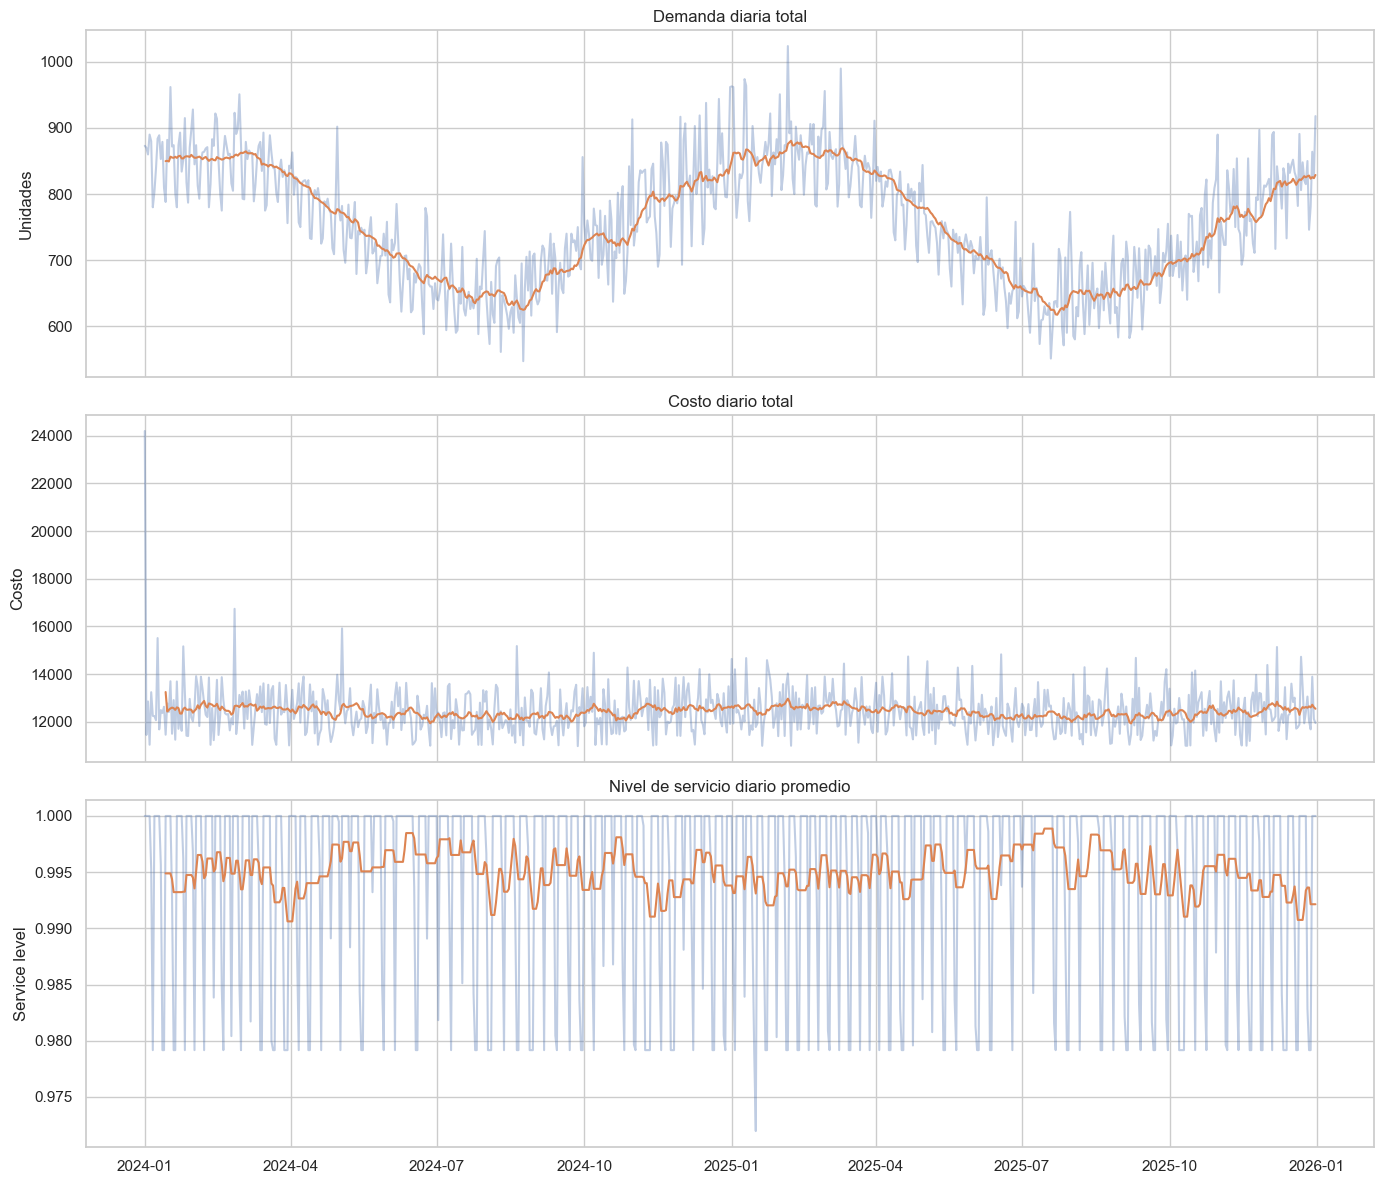


Resumen por clima:
               avg_demand    avg_cost  avg_service  avg_stockout  avg_risk
weather_state                                                             
white_wind      15.849341  259.685171     0.994644      0.006709  0.321611
cloudy          15.417083  259.131246     0.995170      0.005750  0.020190
clear           15.996436  258.677872     0.995108      0.006647  0.020041

Top minas por costo total:
           total_cost  avg_service  stockout_rate  avg_risk
mine_name                                                  
Mine_04    1254277.61     0.999921       0.000228  0.096468
Mine_01    1246382.93     1.000000       0.000000  0.082832
Mine_06    1191216.62     1.000000       0.000000  0.097629
Mine_03    1156337.64     1.000000       0.000000  0.082399
Mine_02    1132745.03     0.960212       0.050616  0.125606
Mine_05    1043338.69     1.000000       0.000000  0.080187
Mine_08    1035824.56     1.000000       0.000000  0.081008
Mine_07    1030364.59     1.000000   

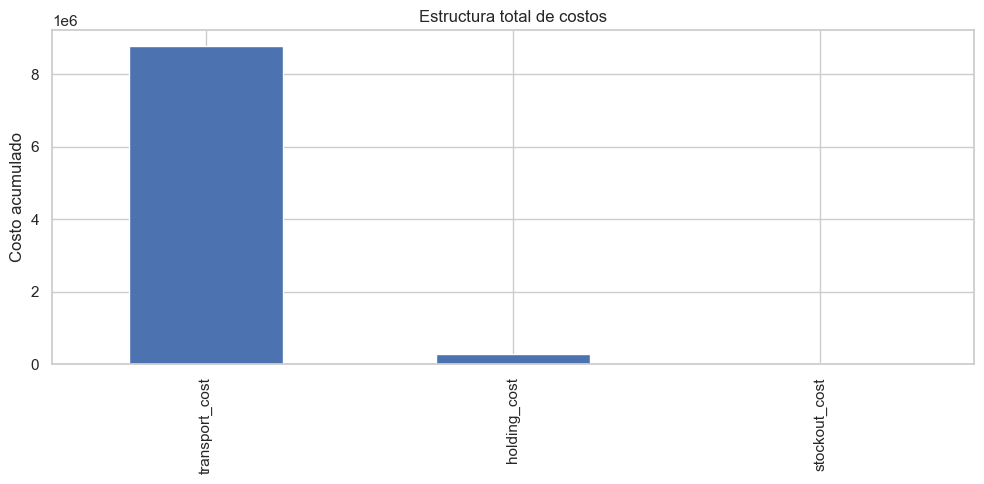

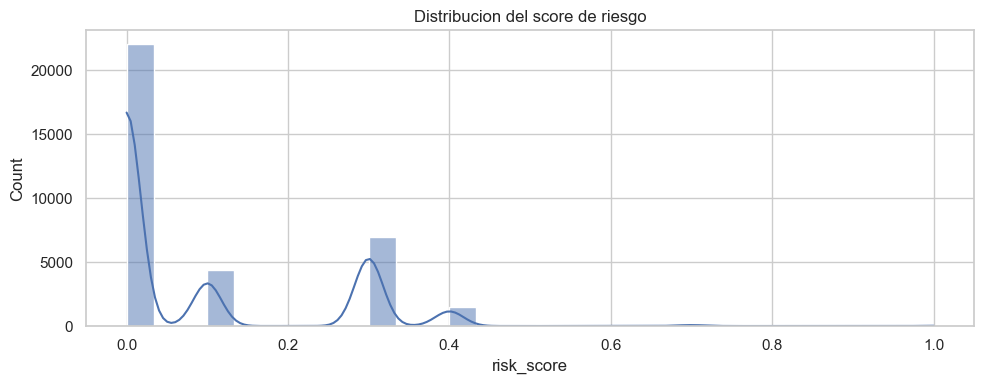

In [18]:
# =========================================================
# 12) Analisis exploratorio orientado a negocios.
# =========================================================

print_section("8. EDA orientado a negocio")

print(f"Costo total: {df['total_cost'].sum():,.2f}")
print(f"Servicio promedio: {df['service_level'].mean():.4f}")
print(f"Tasa de stockout: {df['is_stockout'].mean():.4f}")
print(f"Proporción de white wind: {(df['weather_state'] == 'white_wind').mean():.4f}")

daily_demand = df.groupby("date", as_index=False)["demand_units"].sum()
daily_cost = df.groupby("date", as_index=False)["total_cost"].sum()
daily_service = df.groupby("date", as_index=False)["service_level"].mean()

fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=True)

axes[0].plot(daily_demand["date"], daily_demand["demand_units"], alpha=0.35)
axes[0].plot(daily_demand["date"], daily_demand["demand_units"].rolling(14).mean())
axes[0].set_title("Demanda diaria total")
axes[0].set_ylabel("Unidades")

axes[1].plot(daily_cost["date"], daily_cost["total_cost"], alpha=0.35)
axes[1].plot(daily_cost["date"], daily_cost["total_cost"].rolling(14).mean())
axes[1].set_title("Costo diario total")
axes[1].set_ylabel("Costo")

axes[2].plot(daily_service["date"], daily_service["service_level"], alpha=0.35)
axes[2].plot(daily_service["date"], daily_service["service_level"].rolling(14).mean())
axes[2].set_title("Nivel de servicio diario promedio")
axes[2].set_ylabel("Service level")

plt.tight_layout()
plt.show()

weather_summary = df.groupby("weather_state").agg(
    avg_demand=("demand_units", "mean"),
    avg_cost=("total_cost", "mean"),
    avg_service=("service_level", "mean"),
    avg_stockout=("is_stockout", "mean"),
    avg_risk=("risk_score", "mean"),
).sort_values("avg_cost", ascending=False)

print("\nResumen por clima:")
print(weather_summary.to_string())

mine_summary = df.groupby("mine_name").agg(
    total_cost=("total_cost", "sum"),
    avg_service=("service_level", "mean"),
    stockout_rate=("is_stockout", "mean"),
    avg_risk=("risk_score", "mean"),
).sort_values("total_cost", ascending=False)

print("\nTop minas por costo total:")
print(mine_summary.head(10).to_string())

item_summary = df.groupby("item_name").agg(
    total_cost=("total_cost", "sum"),
    avg_service=("service_level", "mean"),
    stockout_rate=("is_stockout", "mean"),
    avg_demand=("demand_units", "mean"),
).sort_values("total_cost", ascending=False)

print("\nTop ítems por costo total:")
print(item_summary.to_string())

fig, ax = plt.subplots(figsize=(10, 5))
cost_components = df[["holding_cost", "stockout_cost", "transport_cost"]].sum().sort_values(ascending=False)
cost_components.plot(kind="bar", ax=ax)
ax.set_title("Estructura total de costos")
ax.set_ylabel("Costo acumulado")
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(10, 4))
sns.histplot(df["risk_score"], bins=30, kde=True, ax=ax)
ax.set_title("Distribucion del score de riesgo")
plt.tight_layout()
plt.show()


9. Correlaciones


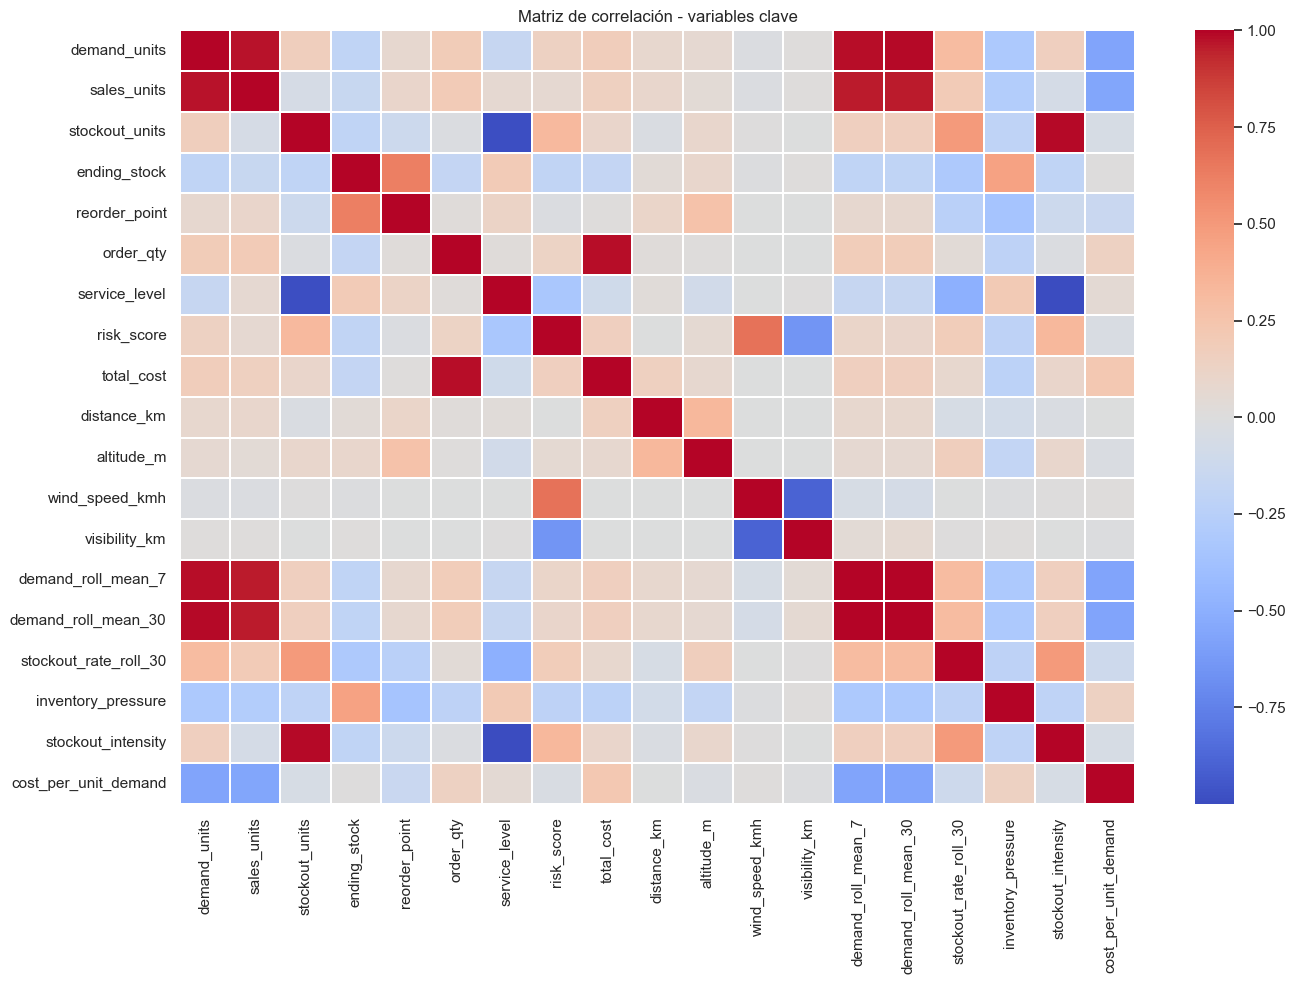

In [19]:
# =========================================================
# 13) Matriz de correlacion.
# =========================================================

print_section("9. Correlaciones")

num_cols = [
    "demand_units",
    "sales_units",
    "stockout_units",
    "ending_stock",
    "reorder_point",
    "order_qty",
    "service_level",
    "risk_score",
    "total_cost",
    "distance_km",
    "altitude_m",
    "wind_speed_kmh",
    "visibility_km",
    "demand_roll_mean_7",
    "demand_roll_mean_30",
    "stockout_rate_roll_30",
    "inventory_pressure",
    "stockout_intensity",
    "cost_per_unit_demand",
]

corr = df[num_cols].corr(numeric_only=True)

plt.figure(figsize=(14, 10))
sns.heatmap(corr, cmap="coolwarm", center=0, linewidths=0.2)
plt.title("Matriz de correlación - variables clave")
plt.tight_layout()
plt.show()

In [20]:
# =========================================================
# 14) Deteccion basica de outliers.
# =========================================================

print_section("10. Deteccion basica de outliers")

outlier_cols = ["demand_units", "total_cost", "risk_score", "ending_stock", "order_qty"]
outlier_report = []
for col in outlier_cols:
    mask = detect_outliers_iqr(df[col])
    outlier_report.append({
        "column": col,
        "outlier_count": int(mask.sum()),
        "outlier_rate": round(mask.mean(), 4),
    })

outlier_report_df = pd.DataFrame(outlier_report).sort_values("outlier_rate", ascending=False)
print(outlier_report_df.to_string(index=False))


10. Deteccion basica de outliers
      column  outlier_count  outlier_rate
  risk_score           8642        0.2463
demand_units           5650        0.1610
  total_cost           2040        0.0581
   order_qty           1855        0.0529
ending_stock            114        0.0032


In [21]:
# =========================================================
# 15) Seleccion de features candidatas para modelado.
# =========================================================

print_section("11. Seleccion de features")

id_columns = [
    "date",
    "mine_id",
    "mine_name",
    "item_id",
    "item_name",
    "supplier_id",
    "supplier_name",
]

potential_feature_columns = [col for col in df.columns if col not in id_columns]
print(f"Numero de columnas candidatas: {len(potential_feature_columns)}")
print(potential_feature_columns[:30])


11. Seleccion de features
Numero de columnas candidatas: 98
['altitude_m', 'distance_km', 'priority_level', 'unit_cost', 'holding_cost_factor', 'criticality', 'base_consumption', 'day_of_year', 'month', 'quarter', 'is_weekend', 'is_month_end', 'temperature_c', 'wind_speed_kmh', 'visibility_km', 'weather_state', 'demand_units', 'initial_stock', 'stock_before_demand', 'received_units', 'sales_units', 'stockout_units', 'ending_stock', 'reorder_point', 'target_stock', 'order_qty', 'emergency_order_qty', 'pipeline_orders', 'holding_cost', 'stockout_cost']


In [22]:
# =========================================================
# 16) Dataset final listo para modelado.
# =========================================================

print_section("12. Exportacion de datasets")

processed_dataset_path = PROCESSED_DIR / "feature_engineered_dataset.csv"
df.to_csv(processed_dataset_path, index=False)

# Dataset agregado para dashboard
# Este archivo es ideal para Power BI / Tableau / Streamlit.
dashboard_agg = df.groupby(["date", "weather_state"]).agg(
    demand_units=("demand_units", "sum"),
    total_cost=("total_cost", "sum"),
    avg_service_level=("service_level", "mean"),
    avg_risk_score=("risk_score", "mean"),
    stockout_units=("stockout_units", "sum"),
).reset_index()

dashboard_path = PROCESSED_DIR / "dashboard_daily_agg.csv"
dashboard_agg.to_csv(dashboard_path, index=False)

metadata = pd.DataFrame({
    "dataset_name": ["feature_engineered_dataset"],
    "rows": [len(df)],
    "columns": [df.shape[1]],
    "date_start": [df["date"].min()],
    "date_end": [df["date"].max()],
    "created_features": ["temporal_lags; rolling_means; rolling_stds; ratios; aggregated_business_metrics; cyclical_encodings"],
})
metadata_path = PROCESSED_DIR / "dataset_metadata.csv"
metadata.to_csv(metadata_path, index=False)

print(f"Dataset procesado guardado en: {processed_dataset_path}")
print(f"Agregado diario para dashboard guardado en: {dashboard_path}")
print(f"Metadata guardada en: {metadata_path}")


12. Exportacion de datasets
Dataset procesado guardado en: c:\Users\acer\Documents\PYTHON\Portfolio\02 Mining Supply Chain Decision Intelligence\data\processed\feature_engineered_dataset.csv
Agregado diario para dashboard guardado en: c:\Users\acer\Documents\PYTHON\Portfolio\02 Mining Supply Chain Decision Intelligence\data\processed\dashboard_daily_agg.csv
Metadata guardada en: c:\Users\acer\Documents\PYTHON\Portfolio\02 Mining Supply Chain Decision Intelligence\data\processed\dataset_metadata.csv


In [23]:
# =========================================================
# 17) Split temporal sugerido para el Notebook 03.
# =========================================================

print_section("13. Split temporal sugerido")

cutoff_date = df["date"].quantile(0.80)
train_df = df[df["date"] <= cutoff_date].copy()
test_df = df[df["date"] > cutoff_date].copy()

print(f"Train shape: {train_df.shape}")
print(f"Test shape: {test_df.shape}")
print(f"Cutoff date: {cutoff_date}")

train_path = PROCESSED_DIR / "train_dataset.csv"
test_path = PROCESSED_DIR / "test_dataset.csv"
train_df.to_csv(train_path, index=False)
test_df.to_csv(test_path, index=False)


13. Split temporal sugerido
Train shape: (28080, 104)
Test shape: (7008, 104)
Cutoff date: 2025-08-07 00:00:00


In [24]:
# =========================================================
# 18) Vista previa final.
# =========================================================

print_section("14. Vista previa del dataset enriquecido")
print(df.head(10).to_string(index=False))


14. Vista previa del dataset enriquecido
      date mine_id mine_name  altitude_m  distance_km  priority_level item_id item_name  unit_cost  holding_cost_factor  criticality  base_consumption  day_of_year  month  quarter  is_weekend  is_month_end  temperature_c  wind_speed_kmh  visibility_km weather_state  demand_units supplier_id  initial_stock  stock_before_demand  received_units  sales_units  stockout_units  ending_stock  reorder_point  target_stock  order_qty  emergency_order_qty  pipeline_orders  holding_cost  stockout_cost  transport_cost  total_cost  service_level  fill_rate  risk_score  is_stockout  is_order_day  is_emergency_day  demand_lag_1  demand_lag_7  rolling_demand_7  rolling_demand_30  rolling_stockout_30  rolling_service_30  days_since_order  inventory_turnover_proxy  day_of_week day_of_week_label  is_monday  is_friday  is_quarter_start  is_quarter_end  week_of_year  day_of_month  day_of_year_sin  day_of_year_cos  week_of_year_sin  week_of_year_cos  service_lag_1  st